In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob as glob

In [6]:
plt.style.use('default')
plt.rcParams.update({'font.size': 25})
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

In [7]:
# Choose output directory
odir_f = './figs/'

In [8]:
idirs = list(sorted(glob.glob('../512*Nens_10_DPRK2_*24/')))

for idir in idirs:
    if 'drag' in idir:
        idirs.remove(idir)

print(idirs)

['../512_Nens_10_DPRK2_avgs_kf24/']


# Time Series

../512_Nens_10_DPRK2_avgs_kf24/


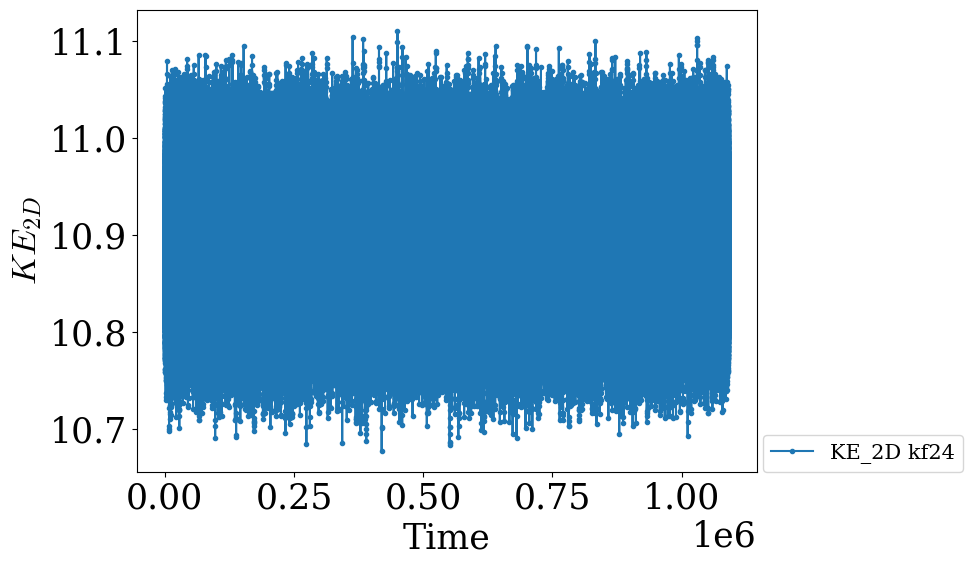

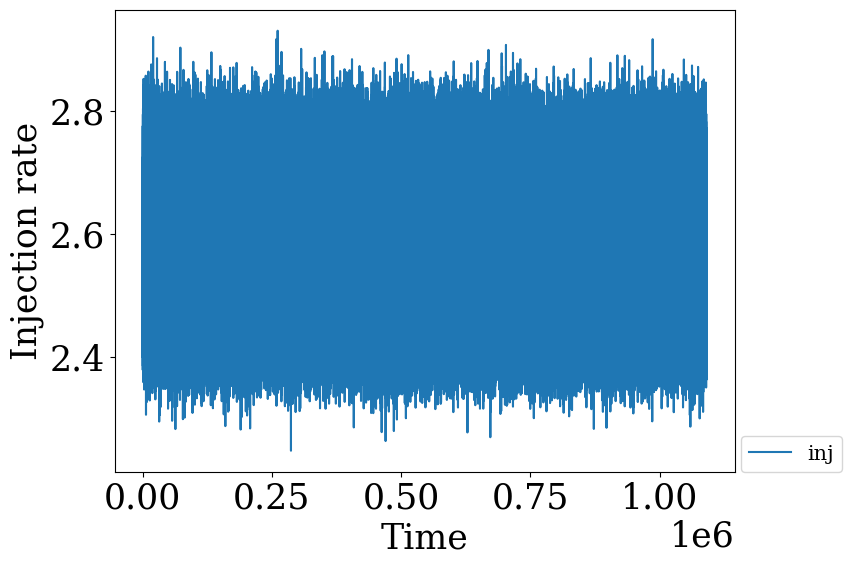

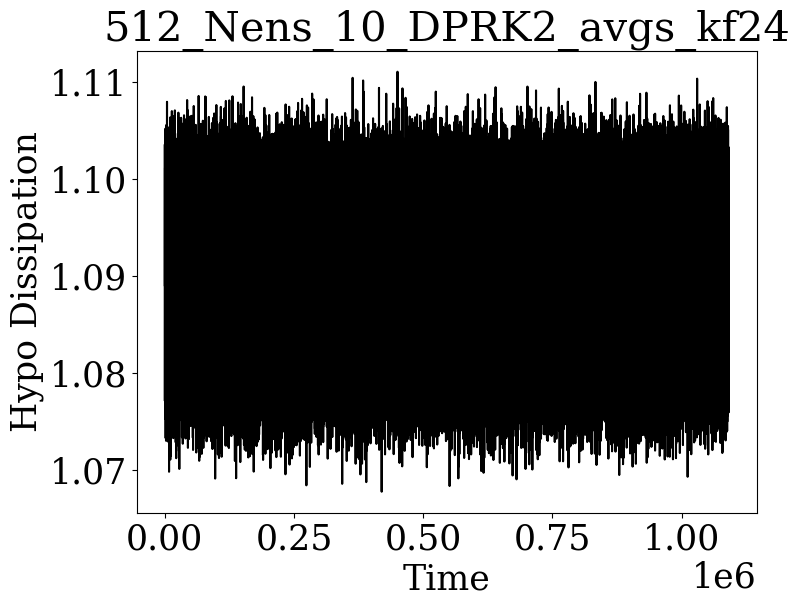

In [11]:
for jj,idir_r in enumerate(idirs[:]):
    print(idir_r)
    runname = idir_r.split('/')[1]
    path = idir_r+'/run/'

    # Load parameter values
    exec(open(path+'parameter.py').read().replace('cupy','numpy'))
    
    # Reads balance.txt
    t,en,inj,diss,hdiss,uf = np.loadtxt(path+'energy_bal.txt',unpack=True)[:,:]
    
    if iflow==3:
        print('random forcing')
        inj = inj/2. # Modify 'measured' injection rate.

    # Time to start plotting
    tsta = 0.0
    
    # Plots
    plt.figure(1,figsize=(8,6))
    plt.plot(t[t>tsta],en[t>tsta],'.-',label='KE_2D '+runname.split('_')[-1],zorder=Nens)
    
    plt.figure(2,figsize=(8,6))
    plt.plot(t[t>tsta],inj[t>tsta],'-',label='inj',zorder=Nens)
            
    plt.figure(3,figsize=(8,6))
    plt.title(runname)
    plt.plot(t[t>tsta],hdiss[t>tsta],'-k',label='hdiss',zorder=Nens)
    

plt.figure(1)
plt.xlabel("Time")
plt.ylabel(r"$KE_{2D}$")
plt.legend(fontsize=15,loc=(1.01,0))

plt.figure(2)
plt.xlabel("Time")
plt.ylabel(r'Injection rate')
plt.legend(fontsize=15,loc=(1.01,0))

plt.figure(3)
plt.ylabel(r"Hypo Dissipation")
plt.xlabel("Time")

plt.show()

# Spectra and Fluxes

------------- 512_Nens_10_DPRK2_avgs_kf24 -------------
Avg injection 2.586339881165874


/tmp/ipykernel_8439/4190210212.py:71: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(np.min(spec_avg)*2,np.max(spec_avg)*2)


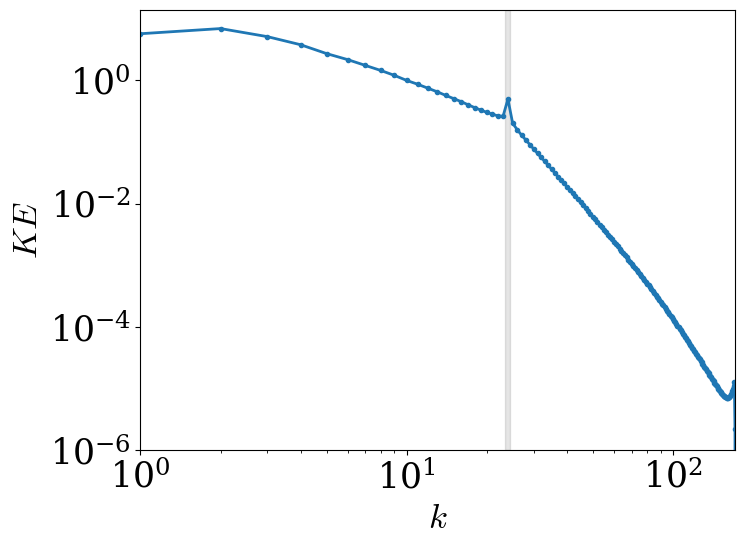

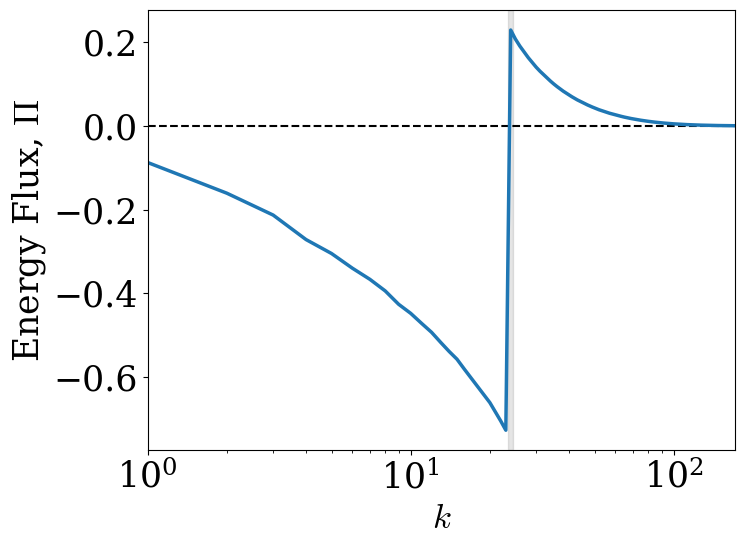

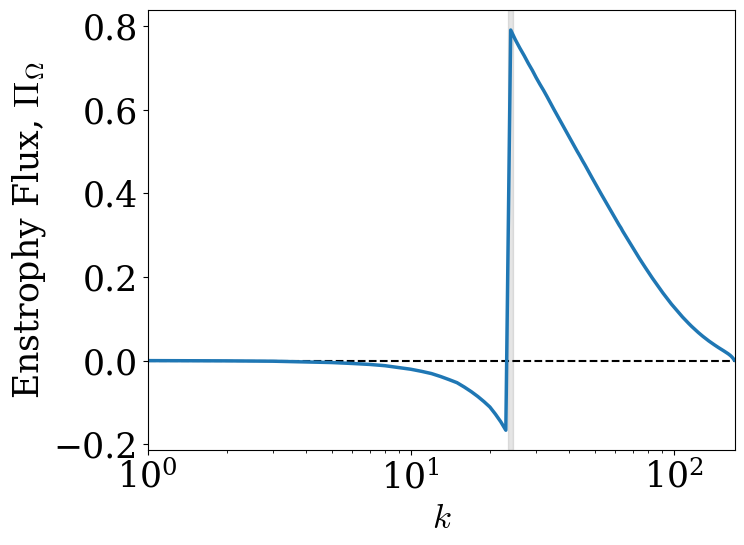

In [13]:
for jj,idir in enumerate(idirs[::-1]):
    runname = idir.split('/')[1]
    path = idir+'outs/'
    path_r = idir+'run/'
    print('------------- %s -------------' % runname)
    
    # # Load parameter values
    exec(open(path_r+'parameter.py').read().replace('cupy','numpy'))

    kf = (kup+kdn)/2

    # Reads balance.txt
    t,en,inj,diss,hdiss,uf = np.loadtxt(path_r+'energy_bal.txt',unpack=True)[:,:]
    
    if iflow==3:
        print('iflow=3')
        inj = inj/2. # RANDOM FORCING

    tavg = 0.0
    
    minj = np.mean(inj[t>tavg])
    Ekf = np.mean(uf[t>tavg])
    print('Avg injection',minj)
    
    specs = sorted(glob.glob(path+'spectrum.*.txt'))
    fluxs = sorted(glob.glob(path+'fluxes.*.txt'))

    # Averaging
    tspec = np.loadtxt(path_r+'time_spec.txt')
    cond = (tspec[:,1]>tavg)
    spec_avg = np.zeros(np.shape(np.loadtxt(specs[0])))
    flux_avg = np.zeros(np.shape(np.loadtxt(fluxs[0])[:,0]))
    fluxEnst_avg = np.zeros(np.shape(np.loadtxt(fluxs[0])[:,0]))
    kplt = np.arange(1,len(spec_avg)+1,dtype=float)

    count = 0
    nskip= 1#10
    for ii,spec in enumerate(specs[:]):
        sp = np.loadtxt(spec)
        if not np.all(np.isnan(sp)):
            k2 = np.arange(1,len(sp)+1)**2
            fl = np.loadtxt(fluxs[ii])[:,1] # KE flux
            flEnst = np.loadtxt(fluxs[ii])[:,0] # Enst flux
            
            # if cond:
            if cond[ii]:
                count += 1
                spec_avg += sp
                flux_avg += fl
                fluxEnst_avg += flEnst


    spec_avg /= count*Ekf
    flux_avg /= count
    fluxEnst_avg /= count

    ## Plot
    plt.figure(1,figsize=(8,6))
    plt.loglog(kplt,spec_avg,'.-',lw=2.)
      
    plt.figure(2,figsize=(8,6))
    plt.semilogx(kplt,flux_avg/minj,'-',lw=2.5)

    plt.figure(3,figsize=(8,6))
    plt.semilogx(kplt,fluxEnst_avg/minj/kf**2,'-',lw=2.5)


plt.figure(1)
plt.xlabel(r'$k$')
plt.ylabel(r'$KE$')
plt.ylim(np.min(spec_avg)*2,np.max(spec_avg)*2)
plt.xlim(kplt[0],kplt[2*(len(spec_avg)-1)//3])
plt.ylim(bottom=1e-6)
ylims = plt.gca().get_ylim()
plt.fill_betweenx(y = np.linspace(ylims[0],ylims[1],100),x1=kdn,x2=kup,color=(0,0,0,0.1))
# plt.legend(loc=3)
plt.tight_layout()

plt.figure(2)
plt.axhline(y=0,c='k',ls='--',lw=1.5,zorder=-10)
plt.xlabel(r'$k$')
plt.ylabel(r'Energy Flux, $\Pi$')
ylim = np.max(np.abs(flux_avg/minj))*1.5
ylims = plt.gca().get_ylim()
plt.ylim(ylims)
plt.fill_betweenx(y = np.linspace(ylims[0],ylims[1],100),x1=kdn,x2=kup,color=(0,0,0,0.1))
plt.xlim(kplt[0],kplt[2*(len(spec_avg)-1)//3])
plt.tight_layout()

plt.figure(3)
plt.axhline(y=0,c='k',ls='--',lw=1.5,zorder=-10)
plt.xlabel(r'$k$')
plt.ylabel(r'Enstrophy Flux, $\Pi_\Omega$')
plt.xlim(kplt[0],kplt[2*(len(spec_avg)-1)//3])
ylims = plt.gca().get_ylim()
plt.ylim(ylims)
plt.fill_betweenx(y = np.linspace(ylims[0],ylims[1],100),x1=kdn,x2=kup,color=(0,0,0,0.1))
plt.tight_layout()
plt.show()

# Snapshots

------------- ../512_Nens_10_DPRK2_avgs_kf24/ -------------
Last output: 783


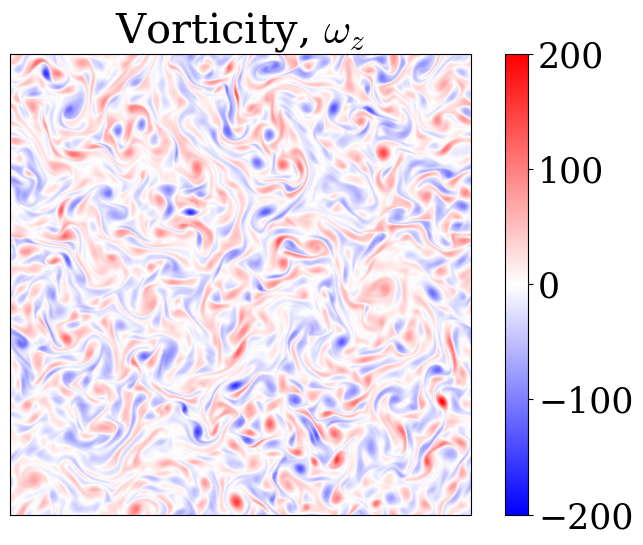

In [14]:
for ii,idir in enumerate(idirs[:]):
    print('------------- %s -------------' % idir)
    dat_temp = dict([])
    runname = idir.split('/')[1]
    path = idir+'outs/'
    path_r = idir+'run/'

    # Load parameter values
    exec(open(path_r+'parameter.py').read().replace('cupy','numpy'))
    idir = idirs[ii]

    tf = np.loadtxt(path_r+'time_field.txt')
    nin = -1
    try:
        lo = int(tf[nin][0])
        time = float(tf[nin][2])
    except:
        lo = int(tf[0])
        time = float(tf[2])
    print("Last output: %s" % lo)

    outnum = str(lo)
    outnum ="{:0>3s}".format(outnum)

    otypes = [
        # 'ps',
        'ww',
    ]
    legends={'ps':r'Streamfunction, $\psi$','ww':r'Vorticity, $\omega_z$'}

    Nens_plt = 1
    for nn in range(Nens_plt):
        # nn+=1
        # Load data
        outs  = dict([])
        datbars = dict([])
        for otype in otypes:
            out = np.load(path+otype+'.'+outnum+'.npy')[nn,:,:]
            outs[otype] = out

            omax = np.max(out)
            omin = np.min(out)
            datbars[otype] = np.max([abs(omax),abs(omin)])

        # Show a horizontal cut of the field in the middle of the box
        for otype in otypes:
            datbar = datbars[otype]
            plt.figure(figsize=(8,6))
            plt.imshow(outs[otype],vmin = -datbar,vmax = datbar,cmap='bwr')
            plt.xticks([])
            plt.yticks([])
            plt.colorbar()
            plt.title(legends[otype])
            plt.tight_layout()
        plt.show()